In [1]:
import sys, os
sys.path.append(os.getcwd().split('src')[0] + 'src')

from utils import *


manifold = Hypersphere(1)
manifold_type = 'S1'

ModuleNotFoundError: No module named 'utils.tools'

# Set Parameters

In [ ]:
n_samples = 5000
sigma2 = .1

# prior param
num_modes = 3
tau2 = 0.05
G = G = lambda n: multimodal_sampler(manifold_type, n, tau2, num_modes) 

# get data
Theta = multimodal_sampler(manifold_type, n_samples, tau2, num_modes)
X = manifold.random_riemannian_normal(Theta, 1./(sigma2), n_samples)

In [ ]:

def select_M_by_DensityKFoldCV(manifold_type, X, M_grid, 
                                n_splits=5,
                                return_scores=False,
                                random_state=None,
                                earlystop = False
                                ):
    '''
    Select the degree M of the Legendre expansion by K-fold cross-validation.

    Parameters
    ----------
    manifold_type : str
    X : np.ndarray
    M_grid : list or np.ndarray
    n_splits : int, optional (default=5)
    return_scores : bool, optional
    random_state : int or None

    Returns
    -------
    dict (or tuple if return_scores=True)
    '''
    M_grid = np.array(M_grid)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    cv_scores = np.zeros_like(M_grid, dtype=float)
    for ixM, M in enumerate(M_grid):

        fold_scores = []
        for train_idx, val_idx in tqdm(kf.split(X),desc=f'kfold (M={M})',leave=False):
            X_train = X[train_idx]
            X_val = X[val_idx]
            hat_f_square_integral = np.square(density_estimate(manifold_type, X_train, M, X_val, grad=False)[1]).mean()
            val_int = density_estimate(manifold_type, X_train, M, X_val, grad=False)[1].mean()
            fold_scores.append(hat_f_square_integral - 2 * val_int)

        cv_scores[ixM] = np.mean(fold_scores)
   
    n = len(X_train)
    k_vals = np.array([spectral_dimension(manifold_type, M) for M in M_grid])
    AIC_scores = cv_scores + 2 * k_vals / n
    BIC_scores = cv_scores + np.log(n) * k_vals / n
    Mstar = {
        'cv':  M_grid[np.argmin(cv_scores)],
        'AIC': M_grid[np.argmin(AIC_scores)],
        'BIC': M_grid[np.argmin(BIC_scores)],
    }

    if return_scores:
        return Mstar, cv_scores
    else:
        return Mstar
    

In [2]:
M_grid=np.arange(3, 20)
rho_grid = np.linspace(1e-2, .5,50)

fig, [axl,axr] = plt.subplots(1,2, figsize=(12,5))

Mrho , cv_scores =  select_M_rho_by_scoreMatchingKFoldCV(manifold_type, X, M_grid, rho_grid, n_splits=5, return_scores=True, random_state=42)
plot_density_cv_scores(cv_scores, M_grid, rho_grid, axl)

Mrho, cv_scores = select_M_rho_by_DensityKFoldCV(manifold_type, X, M_grid, rho_grid, n_splits=5, return_scores=True, random_state=42)
plot_density_cv_scores(cv_scores, M_grid, rho_grid, axr)
plt.show()



NameError: name 'np' is not defined

In [93]:
Mrho

{'cv': (3, 0.5), 'AIC': (3, 0.5), 'BIC': (3, 0.5)}

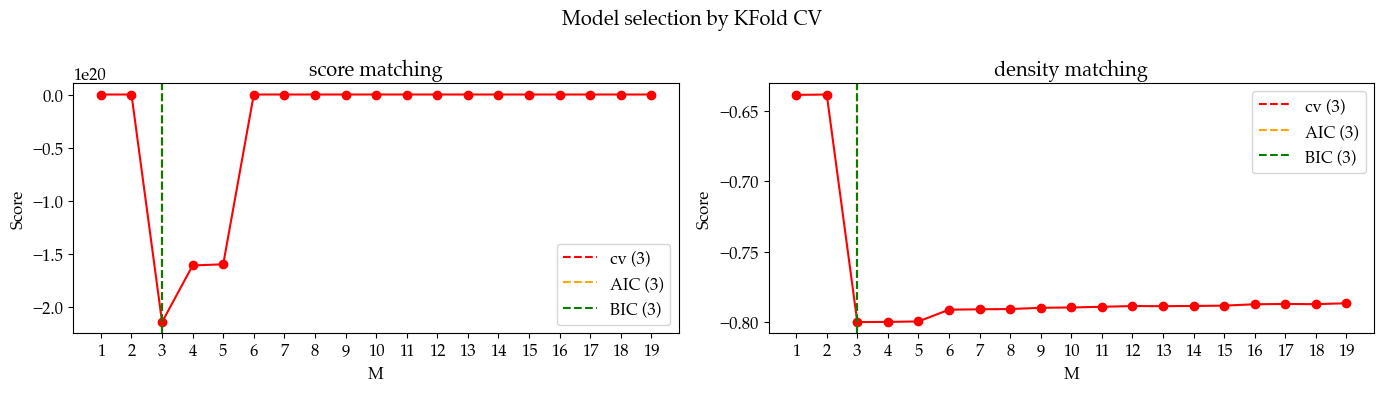

In [ ]:
if True:
    M_grid = np.arange(1, 20)

    selectors = [
        dict(
            title="score matching",
            func=select_M_by_scoreMatchingKFoldCV,
            kwargs=dict(
                n_splits=50,
                return_scores=True,
                random_state=None,
                rho=1e-12,
                tryearlystop=False,
            ),
            line_color="red",
        ),
        dict(
            title="density matching",
            func=select_M_by_DensityKFoldCV,
            kwargs=dict(
                n_splits=50,
                return_scores=True,
            ),
            line_color="red",
        ),
    ]

    results = []
    for s in selectors:
        Mstar, vals = s["func"](manifold_type, X, M_grid, **s["kwargs"])
        results.append((s["title"], Mstar, vals, s["line_color"]))

    if True:
        fig, axs = plt.subplots(1, len(results), figsize=(14, 4), sharex=False, sharey=False)
        fig.suptitle("Model selection by KFold CV")

        if len(results) == 1:
            axs = [axs]

        vlines = [("cv", "red"), ("AIC", "orange"), ("BIC", "green")]

        for ax, (title, Mstar, vals, line_color) in zip(axs, results):
            M_grid_ = M_grid[: len(vals)]
            ax.plot(M_grid_, vals, marker="o", color=line_color)

            for key, c in vlines:
                ax.axvline(Mstar[key], color=c, linestyle="--", label=f"{key} ({Mstar[key]})")

            ax.set_title(title)
            ax.set_xlabel("M")
            ax.set_xticks(M_grid)
            ax.set_ylabel("Score")
            ax.legend()

        plt.tight_layout()
        plt.show()

In [13]:
# for empirical density estimation
M = 3
rho = 0.075
# for oracle approximation
num_oracle_samples = 10000
oracle_bandwidth = 0.001



In [14]:
# --- denoisers
delta = denoiser(manifold_type, X, M, rho, sigma2, X)
oracle_delta_T = oracle_denoiser(manifold_type, num_oracle_samples, sigma2, X, G )
oracle_delta_B = oracle_bayes__kernel(manifold_type, num_oracle_samples, sigma2, oracle_bandwidth, X, G )
# --- losses
loss_N = sq_loss(manifold, X, Theta)
loss_T = sq_loss(manifold, delta, Theta) 
loss_oracle_T = sq_loss(manifold, oracle_delta_T, Theta) 
loss_oracle_B = sq_loss(manifold, oracle_delta_B, Theta) 

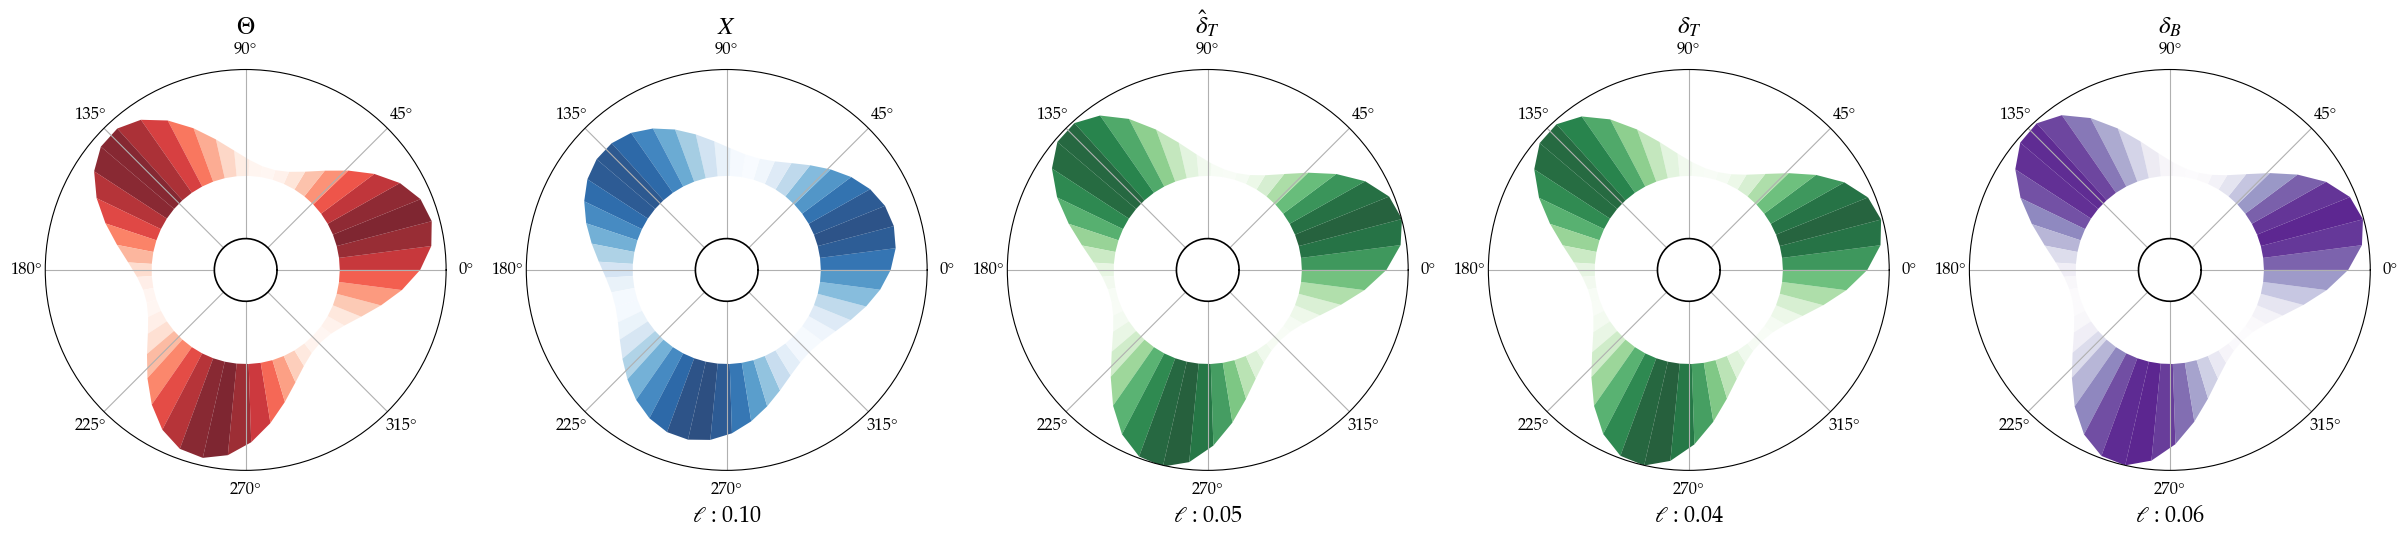

In [15]:
if True:
    fig, axs = plt.subplots(1, 5, figsize=(30, 10), subplot_kw={'polar': True}, sharey=True)

    size = 5.5; jitter_std = 5e-2; alpha = .2
    for ax, data, color in zip(axs, [Theta, X, delta, oracle_delta_T, oracle_delta_B], ['C3', 'C0', 'C2', 'C2', 'C4']):
        S1scatter(data, ax, color, alpha, size, jitter_std)

    nbins, kappa, fscale, bottom, top, disk_r = 50, 8, 1, .3, .5, 0.1
    for ax, data, color in zip(axs, [Theta, X, delta, oracle_delta_T, oracle_delta_B], ['Reds', 'Blues', 'Greens', 'Greens', 'Purples']):
        ax.set_ylim(0,1)
        S1_smooth_histogram(data, ax, color, nbins, kappa, fscale, bottom, top, disk_r)
        # S1_histogram(Theta, nbins, axs[0], 'Reds', .5)

    for ax, title, loss in zip(axs,['$\Theta$', '$X$', '$\hat\delta_T$', '$\delta_T$', '$\delta_B$'],[None, loss_N, loss_T, loss_oracle_T, loss_oracle_B],):
        ax.set_title(title, fontsize=18)
        if title != '$\Theta$':
            ax.set_xlabel(rf'$\ell$ : {loss:.2f}', fontsize=16)

    plt.savefig('denoising_S1.png', bbox_inches='tight')
    plt.show()


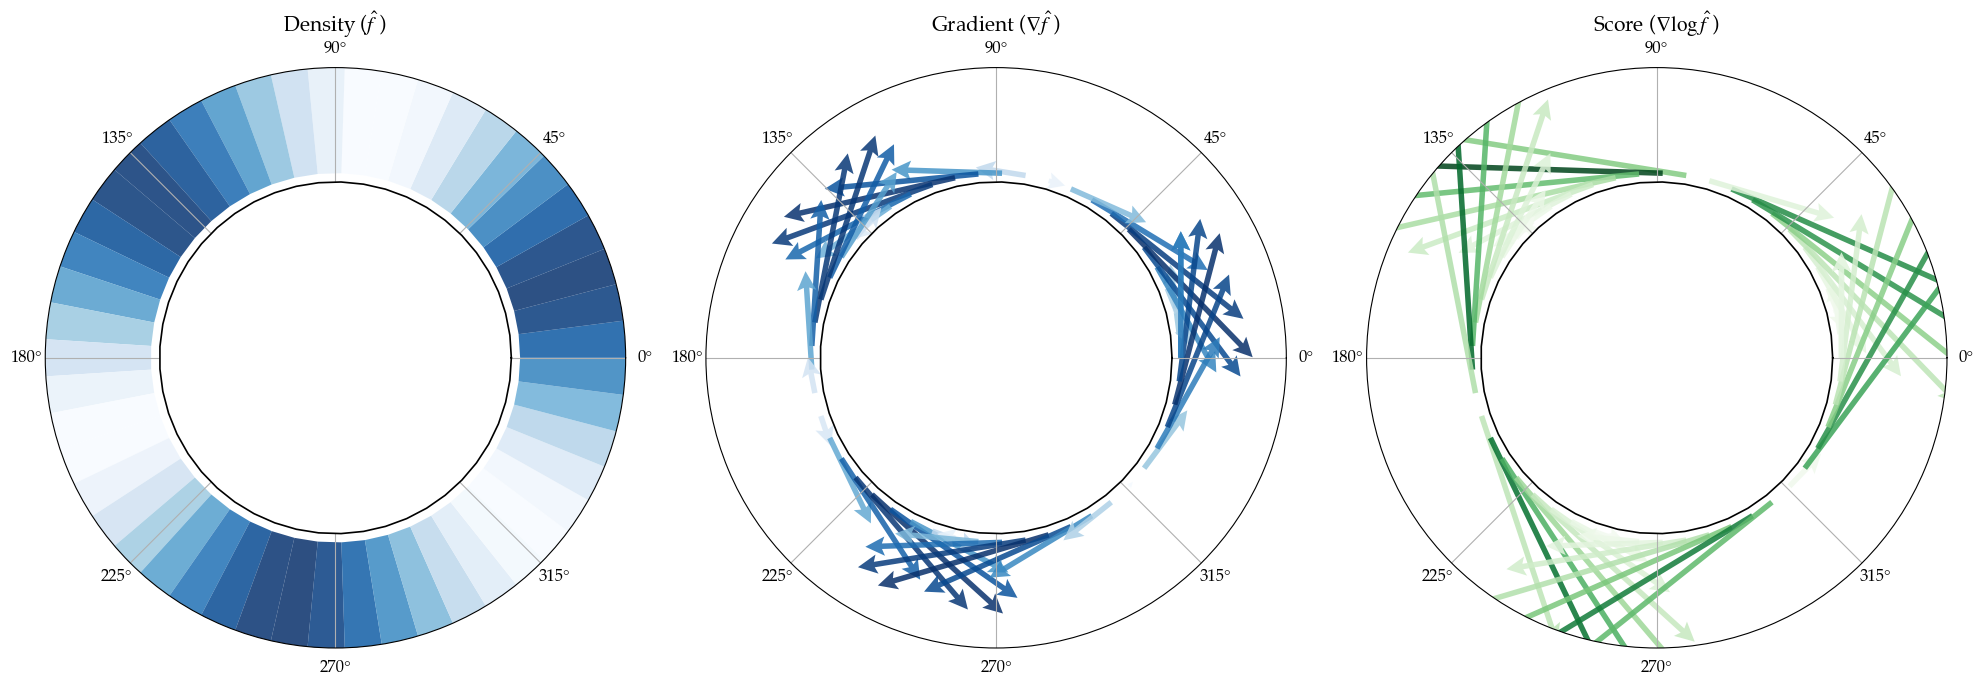

In [12]:
if True:
    f_scale = 0.3
    bottom = 0.105
    top = .5
    disk_r = 0.1

    fig, axs = plt.subplots(1, 3, figsize=(20, 10), subplot_kw={'polar': True})
    grid_I = np.linspace(0, 2*np.pi, 50)
    grid = np.stack([np.cos(grid_I), np.sin(grid_I)], axis=1)
    _, hat_f, hat_grad_f = density_estimate('S1', X, M, grid)
    # ---------- DENSITY ---------------------------------------------------------------------------
    hat_pos_f = np.maximum(hat_f, 0)
    normalised_hat_f = (hat_pos_f - hat_pos_f.min()) / (hat_pos_f.max() - hat_pos_f.min() + 1e-10)
    verts = [[
            (grid_I[i], bottom),
            # (grid_I[i], bottom + f_scale * hat_pos_f[i]), (grid_I[i+1], bottom + f_scale * hat_pos_f[i+1]),
            (grid_I[i],top), (grid_I[i+1], bottom + top),
            (grid_I[i+1], bottom)
        ] for i in range(len(grid_I) - 1)] # Create polygon vertices for each segment
    poly = PolyCollection(verts, facecolors=plt.colormaps['Blues'](normalised_hat_f[:-1]), 
                        alpha=0.85, edgecolors='none')
    axs[0].add_collection(poly)
    axs[0].set_title('Density ($\hat f$)', fontsize=15)
    # ---------- GRADIENT ---------------------------------------------------------------------------
    axs[1].quiver(
        grid_I,                         
        np.ones_like(grid_I)*bottom,    
        hat_grad_f[:, 0],          
        hat_grad_f[:, 1],          
        np.linalg.norm(hat_grad_f, axis=1),                 
        scale=4,           
        width=0.0095,         
        headwidth=3.5,        
        headlength=3.5,       
        headaxislength=3, 
        cmap='Blues',       
        alpha=0.85,         
        edgecolors=None,     
        linewidths=0.25,     
    )
    axs[1].set_title('Gradient ($\\nabla \hat f$)', fontsize=15)
    # ---------- SCORE ---------------------------------------------------------------------------
    hat_score = hat_grad_f /  np.maximum(hat_f.reshape(-1, 1), rho)
    axs[2].quiver(
        grid_I,                         
        np.ones_like(grid_I)*bottom,    
        hat_score[:, 0],          
        hat_score[:, 1],          
        np.linalg.norm(hat_score, axis=1),                 
        scale=7,           
        width=0.0095,         
        headwidth=3.5,        
        headlength=3.5,       
        headaxislength=3, 
        cmap='Greens',       
        alpha=0.85,         
        edgecolors=None,     
        linewidths=0.25,     
    )
    axs[2].set_title('Score ($\\nabla \log \hat f$)', fontsize=15)
    # -------------------------------------------------------------------------------------
    for ax in axs: 
        ax.set_ylim(0, bottom + f_scale*.2)  
        ax.set_yticks([])
        ax.bar(0, disk_r, width=2*np.pi, bottom=0, color="white", edgecolor="none", align="edge", zorder=3)
        ax.plot(grid_I, disk_r*np.ones_like(grid_I), color='black', linewidth=1.2, zorder=4)
    plt.tight_layout()
    plt.show()